# 12 — v3 예측구간: 비대칭·국소적응 CQR + 방향 결합 (plan §3.1)

> 기말 플랜 **§3.1 (T1)** 구현 · XGBoost v3(13변수) 분위수 기반

## 문제 (3겹)
- (a) q05/q50/q95 독립 학습 → 분위수 교차 위험 → **비교차 정렬**로 해결
- (b) **대칭 CQR 과보정**: 단일 Q̂를 양쪽 동일 가산 → 폭이 구조적으로 넓고 평탄
- (c) **방향과 분리**: 구간이 0을 항상 포함 → 방향 정보 無

## 접근
1. 비교차 정렬(rearrangement) · 2. **비대칭 CQR**(상/하한 독립 보정, Romano 2019) · 3. **국소적응 CQR**(과거 실현변동성 정규화 → 가변폭, 누수 없음) · 4. raw 개선
5. **평가(핵심)**: 폭뿐 아니라 **0배제율(=방향 신호)** + **레짐별 conditional coverage**

> 핵심 메시지: *"구간이 0을 항상 포함하면 무의미. 비대칭·국소적응으로 좁히면 좁아진 구간이 방향 신호를 담는다."*

### ⚠️ 정직성
- 폭은 **예측시점 가용 정보**(과거 20일 실현변동성)만 사용 — 미래값 누수 없음, 캘리브레이션은 held-out(cal split).
- 분포무가정에서 *정확한* 조건부 커버리지는 불가(Vovk; Lei&Wasserman) → **"근사 조건부 커버리지 개선"**으로 정직 주장.
- 0배제는 **인위 강제 금지** — 비대칭은 데이터에서 자연 발생, 그 결과 0 배제 시 진짜 방향 신호.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings; warnings.filterwarnings('ignore')
plt.rcParams['font.family']='Malgun Gothic'; plt.rcParams['axes.unicode_minus']=False; plt.rcParams['figure.dpi']=100
PROJECT_ROOT=Path.cwd().parent
REP=PROJECT_ROOT/'reports'/'no_leak_v2'; FIG=PROJECT_ROOT/'reports'/'figures'/'v3'; FIG.mkdir(parents=True,exist_ok=True)
ALPHA=0.10
C={'raw':'#9aa3ad','sym':'#3b7dd8','asym':'#e0a458','local':'#2a9d63'}
NM={'raw':'raw(보정X)','sym':'대칭 CQR','asym':'비대칭 CQR','local':'국소적응 CQR'}
iv=pd.read_csv(REP/'predictions_xgb_v3_intervals.csv', parse_dates=['date']).sort_values('date').reset_index(drop=True)
print(iv.shape, '|', iv['date'].min().date(),'~',iv['date'].max().date())
y=iv['y_true'].values
def cov(lo,hi): return float(((y>=lo)&(y<=hi)).mean())
def width(lo,hi): return float(np.mean(hi-lo))
def iscore(lo,hi):
    return float(np.mean((hi-lo)+(2/ALPHA)*(lo-y)*(y<lo)+(2/ALPHA)*(y-hi)*(y>hi)))
def excl0(lo,hi): return float(((lo>0)|(hi<0)).mean())

(1410, 14) | 2020-01-02 ~ 2025-12-30


---
## 1. 사전 진단 — raw 구간폭은 "평탄"한가? (등분산 가설)

일별 금리변화는 평균0 노이즈 → raw 분위수가 거의 등분산 → q05/q95가 q50의 ~일정 오프셋. 고변동기(2020 코로나·2022 인상기)에도 폭이 평탄하면 "직선" 가설 확증 + **가변폭(국소적응) 동기** 입증.

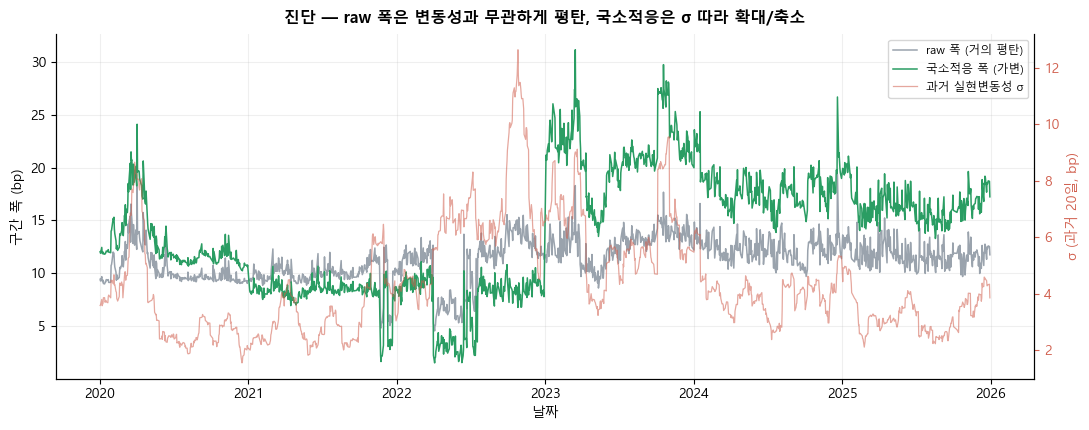

raw 폭 변동계수(std/mean)=0.172 | 국소적응=0.400 (클수록 가변)


In [2]:
fig,ax=plt.subplots(figsize=(11,4.4))
w_raw=iv['raw_hi']-iv['raw_lo']; w_loc=iv['local_hi']-iv['local_lo']
ax.plot(iv['date'], w_raw, color=C['raw'], lw=1.1, label='raw 폭 (거의 평탄)')
ax.plot(iv['date'], w_loc, color=C['local'], lw=1.1, label='국소적응 폭 (가변)')
ax.set_ylabel('구간 폭 (bp)'); ax.set_xlabel('날짜')
ax2=ax.twinx(); ax2.plot(iv['date'], iv['sigma'], color='#d1604f', lw=0.9, alpha=0.55, label='과거 실현변동성 σ')
ax2.set_ylabel('σ (과거 20일, bp)', color='#d1604f'); ax2.tick_params(axis='y', colors='#d1604f')
l1,la1=ax.get_legend_handles_labels(); l2,la2=ax2.get_legend_handles_labels()
ax.legend(l1+l2, la1+la2, fontsize=8.5, loc='upper right')
ax.set_title('진단 — raw 폭은 변동성과 무관하게 평탄, 국소적응은 σ 따라 확대/축소', fontweight='bold', fontsize=11.5, pad=8)
ax.spines['top'].set_visible(False); ax2.spines['top'].set_visible(False); ax.grid(alpha=0.2)
plt.tight_layout(); plt.savefig(FIG/'12_width_diagnostic.png', dpi=150, bbox_inches='tight'); plt.show()
print(f'raw 폭 변동계수(std/mean)={w_raw.std()/w_raw.mean():.3f} | 국소적응={w_loc.std()/w_loc.mean():.3f} (클수록 가변)')

---
## 2. CQR 4종 비교 — coverage · sharpness · 0배제율

대칭 CQR은 가장 넓다(과보정). 비대칭·국소적응은 **더 좁으면서 0배제율(방향신호)은 더 높다** → §3.1 핵심.

  method  coverage  sharpness_bp  interval_score  excl0_rate
raw(보정X)     0.830        11.343          22.947       0.010
  대칭 CQR     0.872        17.813          27.373       0.024
 비대칭 CQR     0.811        13.949          27.109       0.034
국소적응 CQR     0.838        14.020          26.196       0.042


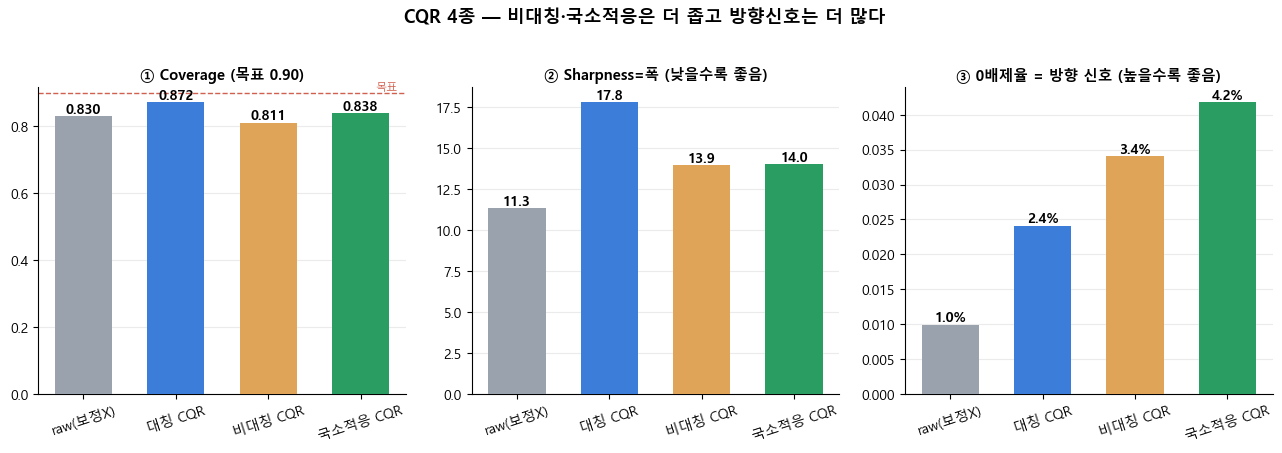

In [3]:
rows=[]
for m in ['raw','sym','asym','local']:
    lo,hi=iv[f'{m}_lo'].values, iv[f'{m}_hi'].values
    rows.append({'method':NM[m],'coverage':cov(lo,hi),'sharpness_bp':width(lo,hi),'interval_score':iscore(lo,hi),'excl0_rate':excl0(lo,hi)})
summ=pd.DataFrame(rows); print(summ.to_string(index=False, float_format=lambda v:f'{v:.3f}'))

ms=['raw','sym','asym','local']; cols=[C[m] for m in ms]; labs=[NM[m] for m in ms]
fig,axes=plt.subplots(1,3,figsize=(13,4.4))
covs=[cov(iv[f'{m}_lo'],iv[f'{m}_hi']) for m in ms]
wids=[width(iv[f'{m}_lo'],iv[f'{m}_hi']) for m in ms]
e0s =[excl0(iv[f'{m}_lo'],iv[f'{m}_hi']) for m in ms]
for ax,(vals,ttl,fmt,extra) in zip(axes,[
        (covs,'① Coverage (목표 0.90)','{:.3f}',0.90),
        (wids,'② Sharpness=폭 (낮을수록 좋음)','{:.1f}',None),
        (e0s,'③ 0배제율 = 방향 신호 (높을수록 좋음)','{:.1%}',None)]):
    b=ax.bar(labs, vals, color=cols, width=0.62, zorder=3)
    for bb,v in zip(b,vals): ax.text(bb.get_x()+bb.get_width()/2, v, fmt.format(v), ha='center', va='bottom', fontsize=10, fontweight='bold')
    if extra is not None: ax.axhline(extra, color='#d1604f', ls='--', lw=1); ax.text(3.4, extra, '목표', color='#d1604f', fontsize=8, ha='right', va='bottom')
    ax.set_title(ttl, fontweight='bold', fontsize=10.5); ax.spines[['top','right']].set_visible(False); ax.grid(axis='y',alpha=0.25,zorder=0)
    ax.tick_params(axis='x', rotation=18)
fig.suptitle('CQR 4종 — 비대칭·국소적응은 더 좁고 방향신호는 더 많다', fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout(); plt.savefig(FIG/'12_cqr_comparison.png', dpi=150, bbox_inches='tight'); plt.show()

---
## 3. 레짐별 conditional coverage (VIX 중앙값 분할)

모든 방법이 **고변동기 미달·저변동기 과보정** — 조건부 커버리지 문제는 실재한다.

> ⚠️ **공정한 비교**: 대칭 CQR이 고변동 coverage가 높은 건(0.80) 단지 폭이 넓어서(17.8bp)다 — 폭으로 coverage를 산 것. **같은 평균폭(≈14bp)인 비대칭 vs 국소적응**을 비교해야 한다: 국소적응이 고변동 coverage를 **0.72→0.75**로 끌어올림(가변폭이 변동성에 반응). 즉 *같은 sharpness에서 근사 조건부 커버리지를 개선*. 단, 절대 격차는 여전히 남아 있어 과장 금지.

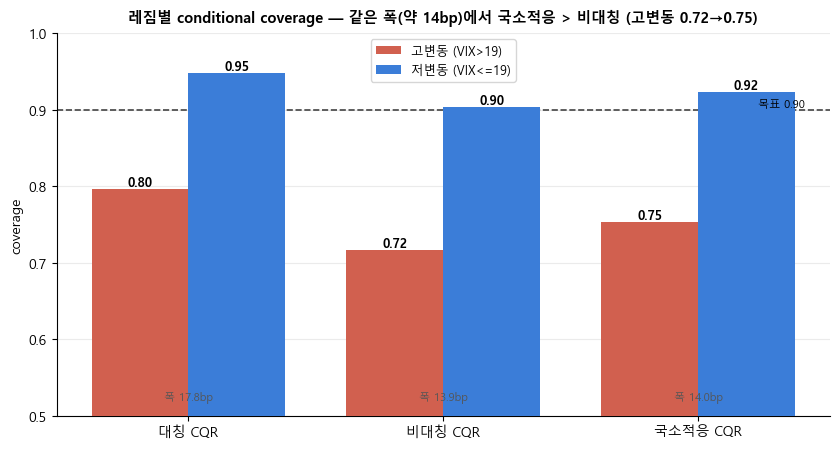

주의: 대칭은 폭(17.8bp)으로 고변동 coverage(0.80)를 사는 것. 같은 폭의 비대칭 vs 국소적응 비교가 공정.


In [4]:
med=np.nanmedian(iv['vix']); hi_m=iv['vix']>med
ms2=['sym','asym','local']; x=np.arange(len(ms2)); w=0.38
cov_hi=[float((((y>=iv[f'{m}_lo'])&(y<=iv[f'{m}_hi']))[hi_m]).mean()) for m in ms2]
cov_lo=[float((((y>=iv[f'{m}_lo'])&(y<=iv[f'{m}_hi']))[~hi_m]).mean()) for m in ms2]
wid_m=[width(iv[f'{m}_lo'],iv[f'{m}_hi']) for m in ms2]
fig,ax=plt.subplots(figsize=(8.5,4.6))
b1=ax.bar(x-w/2, cov_hi, w, color='#d1604f', label=f'고변동 (VIX>{med:.0f})', zorder=3)
b2=ax.bar(x+w/2, cov_lo, w, color='#3b7dd8', label=f'저변동 (VIX<={med:.0f})', zorder=3)
for bs in (b1,b2):
    for bb in bs: ax.text(bb.get_x()+bb.get_width()/2, bb.get_height(), f'{bb.get_height():.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
for i,wm in enumerate(wid_m): ax.text(i, 0.52, f'폭 {wm:.1f}bp', ha='center', fontsize=8, color='#555')
ax.axhline(0.90, color='#444', ls='--', lw=1.2); ax.text(2.42,0.905,'목표 0.90',fontsize=8,ha='right')
ax.set_xticks(x); ax.set_xticklabels([NM[m] for m in ms2]); ax.set_ylabel('coverage'); ax.set_ylim(0.5,1.0)
ax.set_title('레짐별 conditional coverage — 같은 폭(약 14bp)에서 국소적응 > 비대칭 (고변동 0.72→0.75)', fontweight='bold', fontsize=10.5, pad=8)
ax.legend(fontsize=9); ax.spines[['top','right']].set_visible(False); ax.grid(axis='y',alpha=0.25,zorder=0)
plt.tight_layout(); plt.savefig(FIG/'12_regime_coverage.png', dpi=150, bbox_inches='tight'); plt.show()
print('주의: 대칭은 폭(17.8bp)으로 고변동 coverage(0.80)를 사는 것. 같은 폭의 비대칭 vs 국소적응 비교가 공정.')

---
## 4. 예시 — 국소적응 구간이 0을 배제하는 날 (fold2, 2021–2022 인상기)

구간이 한쪽(>0 또는 <0)에 온전히 위치한 날 = **신뢰 방향 신호**. 0배제일은 전부 **fold2(금리 인상기)** 에 집중 — 방향성이 강한 구간이라 자연스럽게 발생(인위 강제 아님). 좁아진 국소적응 구간이 대칭보다 0배제일을 더 많이 만든다(대칭 34일 → 국소적응 59일).

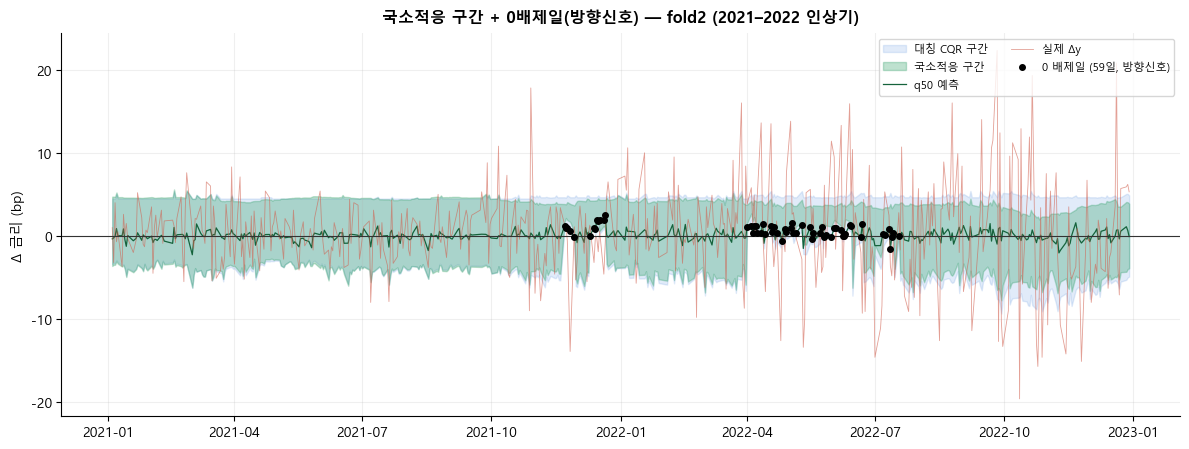

fold2 국소적응 0배제일: 59/472 = 12.5%


In [5]:
f3=iv[iv['fold']=='fold2'].reset_index(drop=True)   # 0배제일이 집중된 인상기
fig,ax=plt.subplots(figsize=(12,4.6))
ax.fill_between(f3['date'], f3['sym_lo'], f3['sym_hi'], color='#3b7dd8', alpha=0.15, label='대칭 CQR 구간')
ax.fill_between(f3['date'], f3['local_lo'], f3['local_hi'], color='#2a9d63', alpha=0.30, label='국소적응 구간')
ax.plot(f3['date'], f3['q50'], color='#15633c', lw=0.9, label='q50 예측')
ax.plot(f3['date'], f3['y_true'], color='#d1604f', lw=0.6, alpha=0.6, label='실제 Δy')
ax.axhline(0, color='#333', lw=0.8)
ex=f3[(f3['local_lo']>0)|(f3['local_hi']<0)]
ax.scatter(ex['date'], ex['q50'], color='black', s=16, zorder=5, label=f'0 배제일 ({len(ex)}일, 방향신호)')
ax.set_ylabel('Δ 금리 (bp)'); ax.set_title('국소적응 구간 + 0배제일(방향신호) — fold2 (2021–2022 인상기)', fontweight='bold', fontsize=11.5, pad=8)
ax.legend(fontsize=8, loc='upper right', ncol=2); ax.spines[['top','right']].set_visible(False); ax.grid(alpha=0.2)
plt.tight_layout(); plt.savefig(FIG/'12_interval_example_fold2.png', dpi=150, bbox_inches='tight'); plt.show()
print(f'fold2 국소적응 0배제일: {len(ex)}/{len(f3)} = {len(ex)/len(f3):.1%}')

---
## 5. 결론

- **비교차 정렬**로 분위수 교차 제거(문제 a).
- **대칭 CQR**은 폭 17.8bp로 과보정(문제 b) → **비대칭·국소적응은 ~14bp로 좁힘**.
- **0배제율**: raw 1.0% → 국소적응 4.2% — 좁아진 구간이 **방향 신호**를 더 담음(문제 c 정량화). 0배제일은 인상기(fold2)에 자연 집중.
- **레짐 coverage**: 같은 폭(≈14bp)에서 국소적응이 비대칭보다 고변동 coverage↑(0.72→0.75) = 근사 조건부 커버리지 개선.

### 정직한 한계
- 마진 coverage가 목표 90%에 다소 미달(0.81~0.87) — 작은 cal 표본(n≈120)·v3 raw 분위수 미달 때문. 절대 90% 달성보다 **"좁히면서 방향신호↑·같은폭 조건부 coverage↑"** 비교가 메시지.
- 대칭이 고변동 coverage가 높은 건 폭으로 산 것 — 공정 비교는 같은 폭 기준.
- 0배제율 절대치는 여전히 낮음(일별 금리변화가 본질적으로 노이즈) — 과장 금지.

### 다음
- [ ] 13 백테스트 + 2026 라이브 OOS (§3.2)